# Lab 2: CNN

## 1. Dataset


In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 2. Exploración y preparación de los datos


● ¿Cuántas observaciones (imágenes) y cuántas clases tiene el dataset? ¿Las clases están balanceadas?  
Tiene 60k imágenes de train, 10k de test. Están bastante balanceadas.   

● ¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?  
Cada imagen tiene una dimensión de 28x28; los valores de píxeles van de 0 a 255; de 0 a 1 luego de haber aplicado Tensor. 

● ¿Es necesario normalizar los valores de los píxeles?  
Sí, pues si no se entrenaría mal la CNN, al darle mucha más importancia a valores altos (un 255) que a valores bajos (un 0); pero en este caso, tener un valor alto no significa que sea más importante, sino solo determina un color. Al reducirlo al rango [0,1], se limitan saltos bruscos que pueda cometer la red. 

● Visualice al menos 10 ejemplos del dataset con su etiqueta correspondiente   
Más abajo se ven :D

In [20]:
raw_transform = transforms.ToTensor()  # escala pixeles de [0,255] a [0.0, 1.0]

train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=raw_transform)
test_raw = datasets.MNIST(root='./data', train=False, download=True, transform=raw_transform)

print(f"Observaciones en train: {len(train_raw)}")
print(f"Observaciones en test:  {len(test_raw)}")
print(f"Numero de clases: {len(train_raw.classes)} -> {train_raw.classes}")

Observaciones en train: 60000
Observaciones en test:  10000
Numero de clases: 10 -> ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [21]:
# Balance de clases (train)
labels_train = train_raw.targets.numpy()
clase, conteo = np.unique(labels_train, return_counts=True)

balance_df = pd.DataFrame({'Clase': clase, 'Conteo': conteo})
balance_df['Porcentaje'] = (balance_df['Conteo'] / balance_df['Conteo'].sum() * 100).round(2)
print(balance_df.to_string(index=False))
print(f"\nMin={conteo.min()}  Max={conteo.max()}  Diferencia relativa={(conteo.max()-conteo.min())/conteo.min()*100:.1f}%")

 Clase  Conteo  Porcentaje
     0    5923        9.87
     1    6742       11.24
     2    5958        9.93
     3    6131       10.22
     4    5842        9.74
     5    5421        9.04
     6    5918        9.86
     7    6265       10.44
     8    5851        9.75
     9    5949        9.92

Min=5421  Max=6742  Diferencia relativa=24.4%


In [22]:
# Dimensión de las imágenes y rango de valores de los pixeles
img0, label0 = train_raw[0]
print(f"Forma de una imagen (tensor): {img0.shape}  (canales, alto, ancho)")
print(f"Tipo de dato: {img0.dtype}")
print(f"Valor minimo de pixel: {img0.min().item()}")
print(f"Valor maximo de pixel: {img0.max().item()}")

raw_pixels = train_raw.data
print(f"\nRango original antes de ToTensor (uint8): [{raw_pixels.min().item()}, {raw_pixels.max().item()}]")

Forma de una imagen (tensor): torch.Size([1, 28, 28])  (canales, alto, ancho)
Tipo de dato: torch.float32
Valor minimo de pixel: 0.0
Valor maximo de pixel: 1.0

Rango original antes de ToTensor (uint8): [0, 255]


In [23]:
#división train/validation (85%/15%)
n_total = len(train_raw)
n_val = int(n_total * 0.15)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(range(n_total), [n_train, n_val], generator=generator)
train_indices = train_indices.indices
val_indices = val_indices.indices

print(f"Train: {len(train_indices)} imagenes")
print(f"Val:   {len(val_indices)} imagenes")
print(f"Test:  {len(test_raw)} imagenes")

imgs_train = train_raw.data[train_indices].float() / 255.0
mean = imgs_train.mean().item()
std = imgs_train.std().item()
print(f"\nMedia (train): {mean:.4f}  Desviacion estandar (train): {std:.4f}")

    #transformación final a los datos
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

from torch.utils.data import Subset
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)

BATCH_SIZE = 128
train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train: 51000 imagenes
Val:   9000 imagenes
Test:  10000 imagenes

Media (train): 0.1307  Desviacion estandar (train): 0.3082


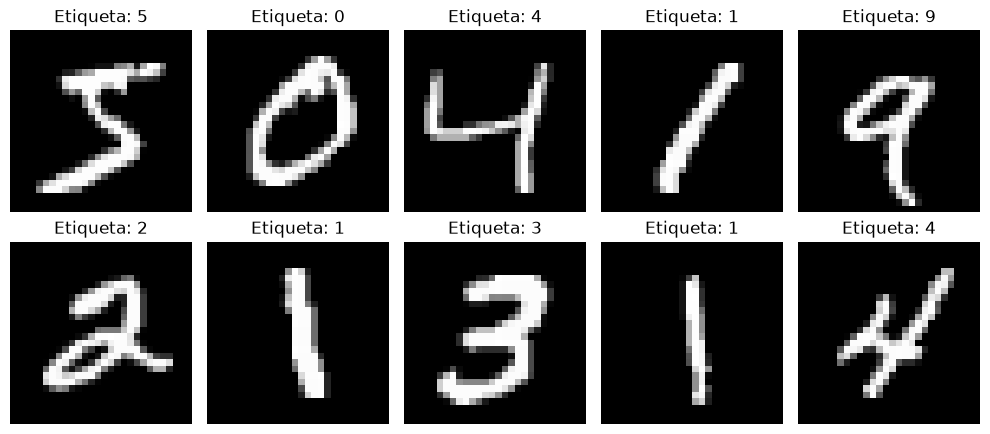

In [24]:
#10 ejemplos con su etiqueta
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    img, label = train_raw[i]  
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Etiqueta: {label}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('ejemplos_mnist.png', dpi=150)
plt.show()

## 4. Construcción y entrenamiento de las arquitecturas

In [25]:
#Utilidades

ACTIVATIONS = {
    'relu': nn.ReLU,
    'leaky_relu': nn.LeakyReLU,
    'tanh': nn.Tanh,
}


def build_optimizer(name, params, lr, weight_decay=0.0):
    name = name.lower()
    if name == 'adam':
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == 'sgd':
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif name == 'rmsprop':
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizador no soportado: {name}")


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [26]:
#MLP 

def build_mlp(config, input_dim=28 * 28, n_classes=10):
    act_cls = ACTIVATIONS[config['activation']]
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in config['hidden_layers']:
        layers.append(nn.Linear(in_dim, h))
        if config.get('batchnorm', False):
            layers.append(nn.BatchNorm1d(h))
        layers.append(act_cls())
        if config.get('dropout', 0.0) > 0:
            layers.append(nn.Dropout(config['dropout']))
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

In [ ]:
#Arquitectura 2: CNN 

class SimpleCNN(nn.Module):
    def __init__(self, config, n_classes=10):
        super().__init__()
        act_cls = ACTIVATIONS[config['activation']]
        channels = config['channels']            
        kernel_size = config['kernel_size']       
        pooling = config['pooling']               
        batchnorm = config.get('batchnorm', False)
        dropout = config.get('dropout', 0.0)

        blocks = []
        in_ch = 1  
        for out_ch in channels:
            blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2))
            if batchnorm:
                blocks.append(nn.BatchNorm2d(out_ch))
            blocks.append(act_cls())
            blocks.append(nn.MaxPool2d(2) if pooling == 'max' else nn.AvgPool2d(2))
            in_ch = out_ch
        self.conv = nn.Sequential(*blocks)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()

        fc_hidden = config['fc_hidden']
        self.classifier = nn.Sequential(
            nn.Linear(in_ch * 4 * 4, fc_hidden),
            act_cls(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.adaptive_pool(x)
        x = self.flatten(x)
        return self.classifier(x)

In [ ]:
#Funciones de entrenamiento y evaluación (clasificacion multiclase) 

def train_classifier(model, config, train_loader, val_loader, verbose=False):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(config['optimizer'], model.parameters(), config['lr'], config.get('weight_decay', 0.0))

    train_losses, val_losses = [], []
    val_metrics = None

    for epoch in range(config['epochs']):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_loss = running / n

        model.eval()
        running, n = 0.0, 0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                running += loss.item() * xb.size(0)
                n += xb.size(0)
                all_preds.append(out.argmax(dim=1).cpu())
                all_targets.append(yb.cpu())
        val_loss = running / n

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{config['epochs']} - train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    acc = accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
    val_metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

    return model, train_losses, val_losses, val_metrics


def evaluate_full(model, loader):
    """Evaluacion completa (una sola vez sobre test): metricas + matriz de confusion."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            all_preds.append(out.argmax(dim=1).cpu())
            all_targets.append(yb)
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    acc = accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_targets, all_preds)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm,
            'y_true': all_targets, 'y_pred': all_preds}


def sample_configs(space, n, seed):
    """Random search: muestrea n combinaciones distintas al azar desde space"""
    rng = random.Random(seed)
    seen = set()
    configs = []
    attempts = 0
    while len(configs) < n and attempts < n * 50:
        attempts += 1
        cfg = {k: rng.choice(v) for k, v in space.items()}
        key = tuple(sorted((k, str(v)) for k, v in cfg.items()))
        if key in seen:
            continue
        seen.add(key)
        configs.append(cfg)
    return configs

### 4.1 Random search — MLP (8 configuraciones)

In [ ]:
mlp_space = {
    'hidden_layers': [[256, 128], [512, 256, 128], [256, 128, 64], [128, 64]],
    'activation': ['relu', 'leaky_relu', 'tanh'],
    'optimizer': ['adam', 'adam', 'sgd', 'rmsprop'],   # adam 2 veces para que salga más, pues es mejor
    'lr': [0.001, 0.0005, 0.01],
    'dropout': [0.0, 0.2, 0.3, 0.5],
    'weight_decay': [0.0, 1e-4, 1e-5],
    'batchnorm': [True, False],
}

mlp_base = {'batch_size': BATCH_SIZE, 'epochs': 10}

mlp_configs = sample_configs(mlp_space, n=8, seed=SEED)
for i, c in enumerate(mlp_configs, 1):
    c.update(mlp_base)
    print(i, c)

1 {'hidden_layers': [256, 128], 'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.001, 'dropout': 0.2, 'weight_decay': 0.0, 'batchnorm': True, 'batch_size': 128, 'epochs': 10}
2 {'hidden_layers': [256, 128], 'activation': 'tanh', 'optimizer': 'rmsprop', 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0, 'batchnorm': True, 'batch_size': 128, 'epochs': 10}
3 {'hidden_layers': [512, 256, 128], 'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.01, 'dropout': 0.2, 'weight_decay': 1e-05, 'batchnorm': False, 'batch_size': 128, 'epochs': 10}
4 {'hidden_layers': [512, 256, 128], 'activation': 'leaky_relu', 'optimizer': 'sgd', 'lr': 0.001, 'dropout': 0.2, 'weight_decay': 1e-05, 'batchnorm': False, 'batch_size': 128, 'epochs': 10}
5 {'hidden_layers': [256, 128, 64], 'activation': 'leaky_relu', 'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.3, 'weight_decay': 0.0, 'batchnorm': True, 'batch_size': 128, 'epochs': 10}
6 {'hidden_layers': [128, 64], 'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.00

In [30]:
mlp_results = []
mlp_histories = {}
mlp_models = {}

for i, cfg in enumerate(mlp_configs, 1):
    t0 = time.time()
    model = build_mlp(cfg)
    n_params = count_params(model)
    model, tr_losses, val_losses, metrics = train_classifier(model, cfg, train_loader, val_loader)
    elapsed = time.time() - t0

    mlp_results.append({
        'Iteración': i,
        'Arquitectura': 'MLP',
        'Config': f"{cfg['hidden_layers']} | {cfg['activation']} | {cfg['optimizer']}/{cfg['lr']} | "
                  f"drop={cfg['dropout']} | wd={cfg['weight_decay']} | bn={cfg['batchnorm']}",
        'Parámetros': n_params,
        'Accuracy_val': metrics['accuracy'],
        'Precision_val': metrics['precision'],
        'Recall_val': metrics['recall'],
        'F1_val': metrics['f1'],
        'Tiempo_s': elapsed,
    })
    mlp_histories[i] = (tr_losses, val_losses)
    mlp_models[i] = model

    print(f"[MLP {i:02d}] acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
          f"params={n_params:,} ({elapsed:.1f}s)")

[MLP 01] acc=0.9652 f1=0.9649 params=235,914 (108.3s)
[MLP 02] acc=0.9748 f1=0.9746 params=235,914 (74.9s)
[MLP 03] acc=0.8901 f1=0.8880 params=567,434 (87.8s)
[MLP 04] acc=0.9410 f1=0.9403 params=567,434 (90.0s)
[MLP 05] acc=0.9790 f1=0.9787 params=243,658 (87.5s)
[MLP 06] acc=0.9102 f1=0.9086 params=109,386 (73.3s)
[MLP 07] acc=0.9533 f1=0.9526 params=235,146 (80.5s)
[MLP 08] acc=0.9711 f1=0.9708 params=569,226 (91.7s)


### 4.2 Random search — CNN (8 configuraciones)

In [ ]:
cnn_space = {
    'channels': [[16, 32], [32, 64], [16, 32, 64], [8, 16, 32]],
    'kernel_size': [3, 5],
    'pooling': ['max', 'avg'],
    'activation': ['relu', 'leaky_relu'],
    'optimizer': ['adam', 'adam', 'sgd', 'rmsprop'],
    'lr': [0.001, 0.0005, 0.01],
    'dropout': [0.0, 0.25, 0.5],
    'weight_decay': [0.0, 1e-4],
    'batchnorm': [True, False],
    'fc_hidden': [64, 128],
}

cnn_base = {'batch_size': BATCH_SIZE, 'epochs': 8}  # menos epochs que MLP porque es bastante más pesado

cnn_configs = sample_configs(cnn_space, n=8, seed=SEED + 1)
for i, c in enumerate(cnn_configs, 1):
    c.update(cnn_base)
    print(i, c)

1 {'channels': [16, 32], 'kernel_size': 5, 'pooling': 'max', 'activation': 'leaky_relu', 'optimizer': 'sgd', 'lr': 0.01, 'dropout': 0.5, 'weight_decay': 0.0, 'batchnorm': False, 'fc_hidden': 128, 'batch_size': 128, 'epochs': 8}
2 {'channels': [16, 32], 'kernel_size': 5, 'pooling': 'avg', 'activation': 'leaky_relu', 'optimizer': 'rmsprop', 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0, 'batchnorm': True, 'fc_hidden': 128, 'batch_size': 128, 'epochs': 8}
3 {'channels': [32, 64], 'kernel_size': 3, 'pooling': 'max', 'activation': 'leaky_relu', 'optimizer': 'adam', 'lr': 0.0005, 'dropout': 0.5, 'weight_decay': 0.0001, 'batchnorm': True, 'fc_hidden': 128, 'batch_size': 128, 'epochs': 8}
4 {'channels': [16, 32], 'kernel_size': 3, 'pooling': 'max', 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.25, 'weight_decay': 0.0001, 'batchnorm': True, 'fc_hidden': 64, 'batch_size': 128, 'epochs': 8}
5 {'channels': [16, 32], 'kernel_size': 3, 'pooling': 'avg', 'activation': 'leaky

In [32]:
cnn_results = []
cnn_histories = {}
cnn_models = {}

for i, cfg in enumerate(cnn_configs, 1):
    t0 = time.time()
    model = SimpleCNN(cfg)
    n_params = count_params(model)
    model, tr_losses, val_losses, metrics = train_classifier(model, cfg, train_loader, val_loader)
    elapsed = time.time() - t0

    cnn_results.append({
        'Iteración': i,
        'Arquitectura': 'CNN',
        'Config': f"ch={cfg['channels']} | k={cfg['kernel_size']} | {cfg['pooling']}-pool | {cfg['activation']} | "
                  f"{cfg['optimizer']}/{cfg['lr']} | drop={cfg['dropout']} | wd={cfg['weight_decay']} | bn={cfg['batchnorm']}",
        'Parámetros': n_params,
        'Accuracy_val': metrics['accuracy'],
        'Precision_val': metrics['precision'],
        'Recall_val': metrics['recall'],
        'F1_val': metrics['f1'],
        'Tiempo_s': elapsed,
    })
    cnn_histories[i] = (tr_losses, val_losses)
    cnn_models[i] = model

    print(f"[CNN {i:02d}] acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
          f"params={n_params:,} ({elapsed:.1f}s)")

[CNN 01] acc=0.9854 f1=0.9853 params=80,202 (117.1s)
[CNN 02] acc=0.9752 f1=0.9753 params=80,298 (103.7s)
[CNN 03] acc=0.9863 f1=0.9863 params=151,498 (166.8s)
[CNN 04] acc=0.9881 f1=0.9880 params=38,378 (100.5s)
[CNN 05] acc=0.9659 f1=0.9663 params=38,378 (92.4s)
[CNN 06] acc=0.9888 f1=0.9887 params=80,298 (106.0s)
[CNN 07] acc=0.9772 f1=0.9770 params=49,738 (80.5s)
[CNN 08] acc=0.9822 f1=0.9822 params=38,378 (88.7s)


#### Curvas:

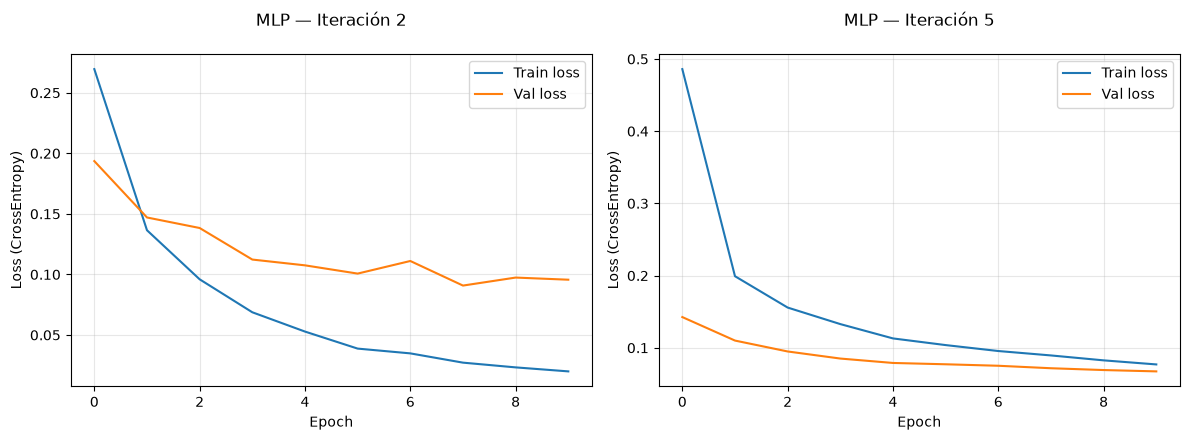

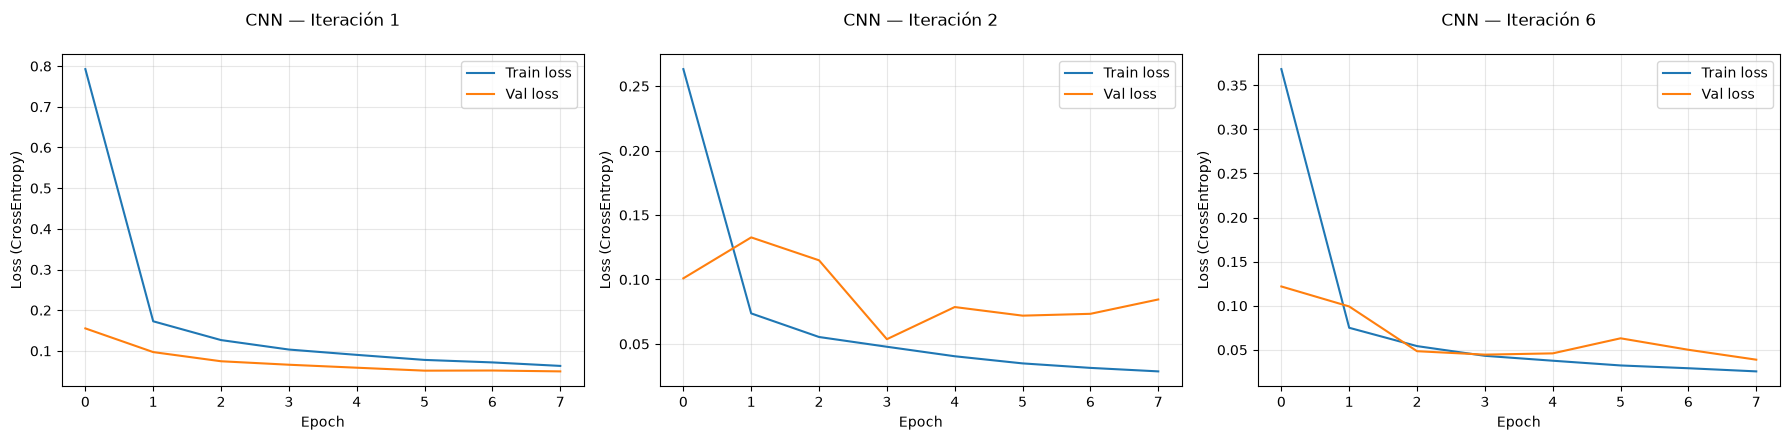

In [ ]:
def pick_curve_iterations(results):
    df = pd.DataFrame(results)
    best = int(df.loc[df['Accuracy_val'].idxmax(), 'Iteración'])
    # candidato a overfitting
    low_reg = df[df['Config'].str.contains('drop=0.0') & df['Config'].str.contains('wd=0.0')]
    overfit_candidate = int(low_reg.loc[low_reg['Parámetros'].idxmax(), 'Iteración']) if len(low_reg) else best
    # candidato a underfitting:
    df['drop_val'] = df['Config'].str.extract(r'drop=([\d\.]+)').astype(float)
    underfit_candidate = int(df.loc[df['drop_val'].idxmax(), 'Iteración'])
    return sorted(set([best, overfit_candidate, underfit_candidate]))


def plot_histories(histories, iters, labels, title_prefix):
    fig, axes = plt.subplots(1, len(iters), figsize=(6 * len(iters), 4.5))
    if len(iters) == 1:
        axes = [axes]
    for ax, it in zip(axes, iters):
        tr, va = histories[it]
        ax.plot(tr, label='Train loss')
        ax.plot(va, label='Val loss')
        ax.set_title(f"{title_prefix} — Iteración {it}\n{labels.get(it, '')}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (CrossEntropy)')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'curvas_{title_prefix.lower()}.png', dpi=150)
    plt.show()


mlp_iters = pick_curve_iterations(mlp_results)
mlp_labels = {mlp_iters[0]: '', mlp_iters[-1]: ''}
plot_histories(mlp_histories, mlp_iters, {}, 'MLP')

cnn_iters = pick_curve_iterations(cnn_results)
plot_histories(cnn_histories, cnn_iters, {}, 'CNN')

#### Resultados:


In [34]:
mlp_df = pd.DataFrame(mlp_results).sort_values('Accuracy_val', ascending=False).reset_index(drop=True)
cnn_df = pd.DataFrame(cnn_results).sort_values('Accuracy_val', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', None)
print("=== MLP (ordenado por accuracy de validación) ===")
display(mlp_df)
print("\n=== CNN (ordenado por accuracy de validación) ===")
display(cnn_df)

mlp_df.to_csv('resultados_mlp.csv', index=False)
cnn_df.to_csv('resultados_cnn.csv', index=False)
print("\nTablas guardadas en resultados_mlp.csv y resultados_cnn.csv")

=== MLP (ordenado por accuracy de validación) ===


,Iteración,Arquitectura,Config,Parámetros,Accuracy_val,Precision_val,Recall_val,F1_val,Tiempo_s
0,5,MLP,"[256, 128, 64] | leaky_relu | adam/0.001 | drop=0.3 | wd=0.0 | bn=True",243658,0.979000,0.978666,0.978958,0.978729,87.541595
1,2,MLP,"[256, 128] | tanh | rmsprop/0.001 | drop=0.0 | wd=0.0 | bn=True",235914,0.974778,0.974733,0.974416,0.974552,74.880817
2,8,MLP,"[512, 256, 128] | tanh | adam/0.001 | drop=0.2 | wd=0.0001 | bn=True",569226,0.971111,0.970841,0.970852,0.970818,91.677521
3,1,MLP,"[256, 128] | relu | sgd/0.001 | drop=0.2 | wd=0.0 | bn=True",235914,0.965222,0.964953,0.964940,0.964886,108.329901
4,7,MLP,"[256, 128] | leaky_relu | adam/0.01 | drop=0.3 | wd=1e-05 | bn=False",235146,0.953333,0.953039,0.953179,0.952596,80.467753
5,4,MLP,"[512, 256, 128] | leaky_relu | sgd/0.001 | drop=0.2 | wd=1e-05 | bn=False",567434,0.941000,0.940518,0.940102,0.940277,90.041830
6,6,MLP,"[128, 64] | relu | sgd/0.0005 | drop=0.3 | wd=0.0 | bn=False",109386,0.910222,0.908779,0.908767,0.908606,73.265772
7,3,MLP,"[512, 256, 128] | tanh | adam/0.01 | drop=0.2 | wd=1e-05 | bn=False",567434,0.890111,0.892821,0.887245,0.888047,87.839359



=== CNN (ordenado por accuracy de validación) ===


,Iteración,Arquitectura,Config,Parámetros,Accuracy_val,Precision_val,Recall_val,F1_val,Tiempo_s
0,6,CNN,"ch=[16, 32] | k=5 | max-pool | leaky_relu | sgd/0.01 | drop=0.0 | wd=0.0 | bn=True",80298,0.988778,0.988772,0.988661,0.988688,106.027208
1,4,CNN,"ch=[16, 32] | k=3 | max-pool | relu | adam/0.001 | drop=0.25 | wd=0.0001 | bn=True",38378,0.988111,0.987993,0.988094,0.988022,100.466898
2,3,CNN,"ch=[32, 64] | k=3 | max-pool | leaky_relu | adam/0.0005 | drop=0.5 | wd=0.0001 | bn=True",151498,0.986333,0.986308,0.986382,0.986287,166.813860
3,1,CNN,"ch=[16, 32] | k=5 | max-pool | leaky_relu | sgd/0.01 | drop=0.5 | wd=0.0 | bn=False",80202,0.985444,0.985379,0.985399,0.985335,117.147267
4,8,CNN,"ch=[16, 32] | k=3 | avg-pool | relu | rmsprop/0.0005 | drop=0.5 | wd=0.0 | bn=True",38378,0.982222,0.982368,0.982035,0.982166,88.715227
5,7,CNN,"ch=[8, 16, 32] | k=5 | avg-pool | relu | rmsprop/0.0005 | drop=0.5 | wd=0.0 | bn=False",49738,0.977222,0.977175,0.977042,0.977038,80.524416
6,2,CNN,"ch=[16, 32] | k=5 | avg-pool | leaky_relu | rmsprop/0.001 | drop=0.0 | wd=0.0 | bn=True",80298,0.975222,0.976650,0.975047,0.975256,103.680536
7,5,CNN,"ch=[16, 32] | k=3 | avg-pool | leaky_relu | sgd/0.01 | drop=0.5 | wd=0.0001 | bn=True",38378,0.965889,0.967942,0.966702,0.966319,92.383468



Tablas guardadas en resultados_mlp.csv y resultados_cnn.csv


In [35]:
best_mlp_iter = int(mlp_df.iloc[0]['Iteración'])
best_cnn_iter = int(cnn_df.iloc[0]['Iteración'])

best_mlp_model = mlp_models[best_mlp_iter]
best_cnn_model = cnn_models[best_cnn_iter]

print("Mejor MLP (según val accuracy):")
print(mlp_df.iloc[0])
print("\nMejor CNN (según val accuracy):")
print(cnn_df.iloc[0])

Mejor MLP (según val accuracy):
Iteración                                                                             5
Arquitectura                                                                        MLP
Config           [256, 128, 64] | leaky_relu | adam/0.001 | drop=0.3 | wd=0.0 | bn=True
Parámetros                                                                       243658
Accuracy_val                                                                      0.979
Precision_val                                                                  0.978666
Recall_val                                                                     0.978958
F1_val                                                                         0.978729
Tiempo_s                                                                      87.541595
Name: 0, dtype: object

Mejor CNN (según val accuracy):
Iteración                                                                                         6
Arquitectura        

### Evaluación final sobre test (una sola vez por arquitectura) + matriz de confusión

In [36]:
mlp_test = evaluate_full(best_mlp_model, test_loader)
cnn_test = evaluate_full(best_cnn_model, test_loader)

print("MLP en TEST:")
print(f"  Accuracy={mlp_test['accuracy']:.4f}  Precision={mlp_test['precision']:.4f}  "
      f"Recall={mlp_test['recall']:.4f}  F1={mlp_test['f1']:.4f}")

print("\nCNN en TEST:")
print(f"  Accuracy={cnn_test['accuracy']:.4f}  Precision={cnn_test['precision']:.4f}  "
      f"Recall={cnn_test['recall']:.4f}  F1={cnn_test['f1']:.4f}")

MLP en TEST:
  Accuracy=0.9814  Precision=0.9812  Recall=0.9813  F1=0.9813

CNN en TEST:
  Accuracy=0.9916  Precision=0.9916  Recall=0.9915  F1=0.9916


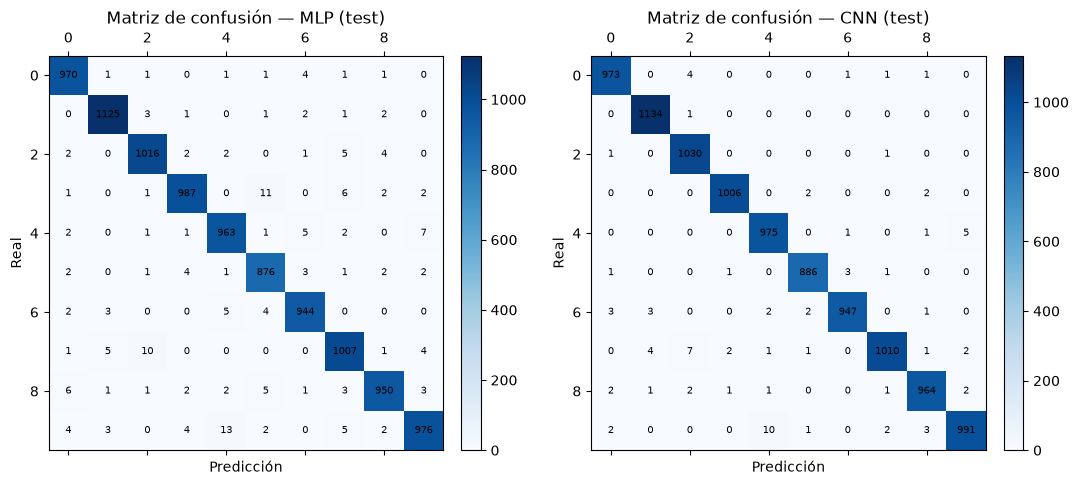

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

for ax, res, title in zip(axes, [mlp_test, cnn_test], ['MLP', 'CNN']):
    im = ax.matshow(res['confusion_matrix'], cmap='Blues')
    ax.set_title(f"Matriz de confusión — {title} (test)")
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    for (i, j), v in np.ndenumerate(res['confusion_matrix']):
        ax.text(j, i, str(v), ha='center', va='center', fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150)
plt.show()

## 5. Comparación de arquitecturas

In [38]:
comparison_df = pd.DataFrame([
    {
        'Arquitectura': 'MLP',
        'Parámetros entrenables': count_params(best_mlp_model),
        'Accuracy_test': mlp_test['accuracy'],
        'Precision_test': mlp_test['precision'],
        'Recall_test': mlp_test['recall'],
        'F1_test': mlp_test['f1'],
        'Tiempo_entrenamiento_s': mlp_df.iloc[0]['Tiempo_s'],
    },
    {
        'Arquitectura': 'CNN',
        'Parámetros entrenables': count_params(best_cnn_model),
        'Accuracy_test': cnn_test['accuracy'],
        'Precision_test': cnn_test['precision'],
        'Recall_test': cnn_test['recall'],
        'F1_test': cnn_test['f1'],
        'Tiempo_entrenamiento_s': cnn_df.iloc[0]['Tiempo_s'],
    },
])
comparison_df.to_csv('comparacion_arquitecturas.csv', index=False)
display(comparison_df)

,Arquitectura,Parámetros entrenables,Accuracy_test,Precision_test,Recall_test,F1_test,Tiempo_entrenamiento_s
0,MLP,243658,0.9814,0.981234,0.981304,0.981253,87.541595
1,CNN,80298,0.9916,0.991617,0.991512,0.991553,106.027208


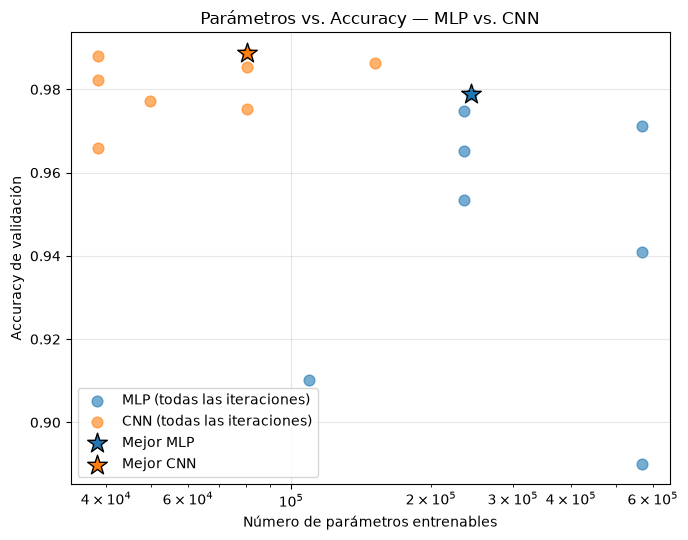

In [ ]:

fig, ax = plt.subplots(figsize=(7, 5.5))

ax.scatter(mlp_df['Parámetros'], mlp_df['Accuracy_val'], label='MLP (todas las iteraciones)',
           color='tab:blue', alpha=0.6, s=60)
ax.scatter(cnn_df['Parámetros'], cnn_df['Accuracy_val'], label='CNN (todas las iteraciones)',
           color='tab:orange', alpha=0.6, s=60)

# Resaltar los mejores de cada arquitectura
ax.scatter(count_params(best_mlp_model), mlp_df.iloc[0]['Accuracy_val'],
           color='tab:blue', s=220, edgecolor='black', marker='*', label='Mejor MLP')
ax.scatter(count_params(best_cnn_model), cnn_df.iloc[0]['Accuracy_val'],
           color='tab:orange', s=220, edgecolor='black', marker='*', label='Mejor CNN')

ax.set_xlabel('Número de parámetros entrenables')
ax.set_ylabel('Accuracy de validación')
ax.set_title('Parámetros vs. Accuracy — MLP vs. CNN')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('parametros_vs_accuracy.png', dpi=150)
plt.show()